In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import os

Versions for libraries imported 

In [2]:
print(np.__version__)
print(matplotlib.__version__)
print(pd.__version__)


1.26.4
3.10.6
2.3.3


In [3]:
FourVehicleFolder="4Vehicle"
EightVehicleFolder="8Vehicle"
TwleveVehicleFolder="12Vehicle"
QUICDataFolder="QUICcsv"
TCPDataFolder="TCPcsv"
CombinedDataOutputFolder='CombinedData'
QUICCSVFiles=[]
TCPCSVFiles=[]
NumOfTrials=5
NumOfIndexs=6
NumOfPERValues=6
#Constants
VEHICLEINDEX=0
PERINDEX=1
AVGDELAYINDEX=2
P95INDEX=3
JITTERINDEX=4
GOODPUTINDEX=5

In [4]:
try:
    os.mkdir(CombinedDataOutputFolder)
except:
    print("error making folder")

error making folder


In [5]:
try:
    QUICCSVFiles=os.listdir(QUICDataFolder+"/"+EightVehicleFolder)
    TCPCSVFiles=os.listdir(TCPDataFolder+"/"+EightVehicleFolder)
    print(QUICCSVFiles)
    print(TCPCSVFiles)
except:
    print("couldn't open folder")

['508_8_Cars_Data_QUIC.csv', '25_8_Cars_Data_QUIC.csv', '567_8_Cars_Data_QUIC.csv', '603_8_Cars_Data_QUIC.csv', '581_8_Cars_Data_QUIC.csv', '254_8_Cars_Data_QUIC.csv', '363_8_Cars_Data_QUIC.csv', '671_8_Cars_Data_QUIC.csv', '391_8_Cars_Data_QUIC.csv', '437_8_Cars_Data_QUIC.csv', '848_8_Cars_Data_QUIC.csv', '774_8_Cars_Data_QUIC.csv', '843_8_Cars_Data_QUIC.csv', '479_8_Cars_Data_QUIC.csv', '474_8_Cars_Data_QUIC.csv', '195_8_Cars_Data_QUIC.csv', '555_8_Cars_Data_QUIC.csv', '702_8_Cars_Data_QUIC.csv', '564_8_Cars_Data_QUIC.csv', '412_8_Cars_Data_QUIC.csv', '325_8_Cars_Data_QUIC.csv', '616_8_Cars_Data_QUIC.csv', '549_8_Cars_Data_QUIC.csv', '696_8_Cars_Data_QUIC.csv', '397_8_Cars_Data_QUIC.csv', '436_8_Cars_Data_QUIC.csv', '55_8_Cars_Data_QUIC.csv', '207_8_Cars_Data_QUIC.csv', '330_8_Cars_Data_QUIC.csv', '851_8_Cars_Data_QUIC.csv', '678_8_Cars_Data_QUIC.csv', '740_8_Cars_Data_QUIC.csv', '804_8_Cars_Data_QUIC.csv', '166_8_Cars_Data_QUIC.csv', '97_8_Cars_Data_QUIC.csv', '184_8_Cars_Data_QUIC.

In [6]:
print(QUICCSVFiles[1])

25_8_Cars_Data_QUIC.csv


In [7]:
QUICarray=np.zeros(shape=(NumOfTrials,NumOfPERValues,NumOfIndexs))
TCParray=np.zeros(shape=(NumOfTrials,NumOfPERValues,NumOfIndexs))
for i in range(0,NumOfTrials):
    QUICarray[i]=np.loadtxt(QUICDataFolder+"/"+EightVehicleFolder+"/"+QUICCSVFiles[i],delimiter=',',dtype=float,skiprows=1)
    TCParray[i]=np.loadtxt(TCPDataFolder+"/"+EightVehicleFolder+"/"+TCPCSVFiles[i],delimiter=',',dtype=float,skiprows=1)



AverageQUICResults=np.zeros(shape=(NumOfPERValues,NumOfIndexs))
AverageTCPResults=np.zeros(shape=(NumOfPERValues,NumOfIndexs))
MedianQUICResults=np.zeros(shape=(NumOfPERValues,NumOfIndexs))
MedianTCPResults=np.zeros(shape=(NumOfPERValues,NumOfIndexs))
for i in range(0,NumOfIndexs):
    for j in range(0,NumOfPERValues):
        AverageQUICResults[j,i]=np.average(QUICarray[0:,j,i])
        AverageTCPResults[j,i]=np.average(TCParray[0:,j,i])
        MedianQUICResults[j,i]=np.median(QUICarray[0:,j,i])
        MedianTCPResults[j,i]=np.median(TCParray[0:,j,i])

In [9]:
# Source - https://stackoverflow.com/a/58106536
# Posted by Dennis Golomazov, modified by community. See post 'Timeline' for change history
# Retrieved 2026-03-25, License - CC BY-SA 4.0

import numpy as np

def format_float(num):
    return np.format_float_positional(num, precision=1, trim='-')


In [10]:
for i in range(0,NumOfPERValues):
    AverageQUICResults[i,VEHICLEINDEX]=format_float(AverageQUICResults[i,VEHICLEINDEX])
    AverageTCPResults[i,VEHICLEINDEX]=format_float(AverageTCPResults[i,VEHICLEINDEX])


In [11]:
print(AverageQUICResults)
CombinedFileName="Combined8.csv"
np.savetxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,AverageQUICResults,delimiter=',')
np.savetxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,AverageTCPResults,delimiter=',')


[[8.0000000e+00 0.0000000e+00 3.7719160e+01 1.2903348e+02 1.0277802e+01
  4.4999920e-01]
 [8.0000000e+00 5.0000000e-03 1.0817120e+01 4.2235160e+01 5.3432540e+00
  4.2640420e-01]
 [8.0000000e+00 1.0000000e-02 6.3388680e+01 2.2275802e+02 1.4820808e+01
  4.3574000e-01]
 [8.0000000e+00 2.0000000e-02 1.2009778e+01 3.9518780e+01 5.8977680e+00
  4.0302160e-01]
 [8.0000000e+00 5.0000000e-02 6.8160260e+01 2.3713504e+02 1.3676054e+01
  4.0888780e-01]
 [8.0000000e+00 1.0000000e-01 6.4329920e+01 1.8513798e+02 1.4325192e+01
  3.8039360e-01]]


In [12]:
def PlotQUICVsTCP(QUICArray,TCPArray,Title,XLabel,YLabel):
    plt.plot(QUICArray[0:,0],QUICArray[0:,1],label="QUIC")
    plt.plot(TCPArray[0:,0],TCPArray[0:,1],label="TCP")
    plt.legend()
    plt.xlabel(XLabel)
    plt.ylabel(YLabel)
    plt.title(Title)
    plt.show()

Average results


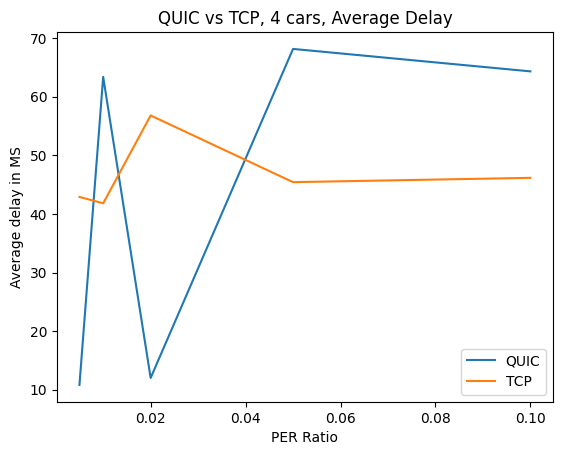

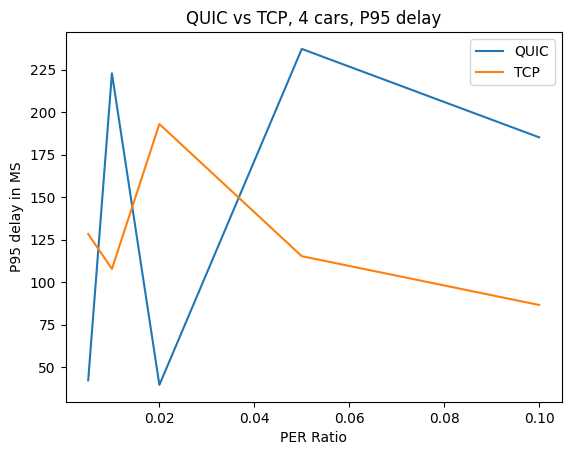

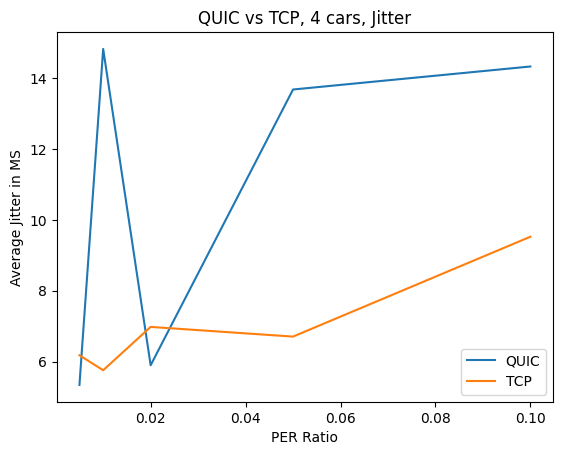

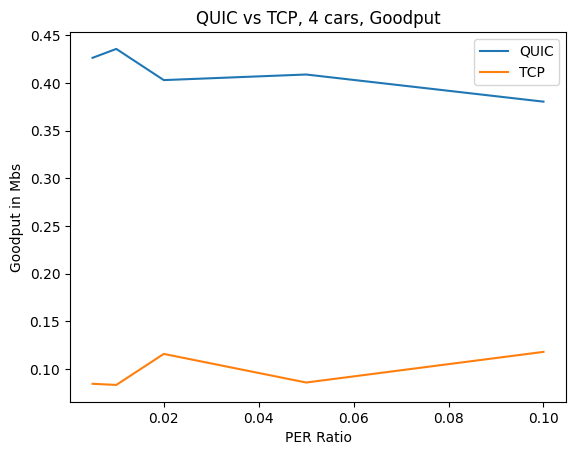

In [ ]:
print("Average results")
#Plot AverageDelay
AvgDelayArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,AVGDELAYINDEX))
AvgDelayArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,AVGDELAYINDEX))

PlotQUICVsTCP(AvgDelayArrayQUIC,AvgDelayArrayTCP,"QUIC vs TCP, 8 cars, Average Delay","PER Ratio","Average delay in MS")
##Plot P95 Latency
P95ArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,P95INDEX))
P95ArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,P95INDEX))

PlotQUICVsTCP(P95ArrayQUIC,P95ArrayTCP,"QUIC vs TCP, 8 cars, P95 delay","PER Ratio","P95 delay in MS")
##plot Average Jitter
JitterArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,JITTERINDEX))
JitterArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,JITTERINDEX))

PlotQUICVsTCP(JitterArrayQUIC,JitterArrayTCP,"QUIC vs TCP, 8 cars, Jitter","PER Ratio","Average Jitter in MS")
##Plot goodput
GoodputArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,GOODPUTINDEX))
GoodputArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,GOODPUTINDEX))

PlotQUICVsTCP(GoodputArrayQUIC,GoodputArrayTCP,"QUIC vs TCP, 8 cars, Goodput","PER Ratio","Goodput in Mbs")

In [14]:
print(AverageQUICResults)
CombinedFileName="Combined8.csv"
np.savetxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,MedianQUICResults,delimiter=',')
np.savetxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,MedianTCPResults,delimiter=',')

[[8.0000000e+00 0.0000000e+00 3.7719160e+01 1.2903348e+02 1.0277802e+01
  4.4999920e-01]
 [8.0000000e+00 5.0000000e-03 1.0817120e+01 4.2235160e+01 5.3432540e+00
  4.2640420e-01]
 [8.0000000e+00 1.0000000e-02 6.3388680e+01 2.2275802e+02 1.4820808e+01
  4.3574000e-01]
 [8.0000000e+00 2.0000000e-02 1.2009778e+01 3.9518780e+01 5.8977680e+00
  4.0302160e-01]
 [8.0000000e+00 5.0000000e-02 6.8160260e+01 2.3713504e+02 1.3676054e+01
  4.0888780e-01]
 [8.0000000e+00 1.0000000e-01 6.4329920e+01 1.8513798e+02 1.4325192e+01
  3.8039360e-01]]


Median results


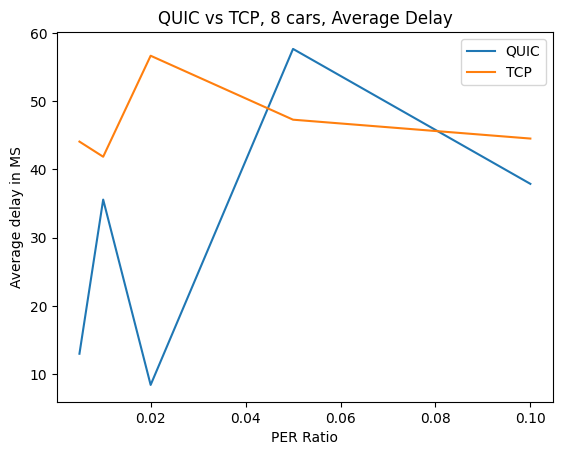

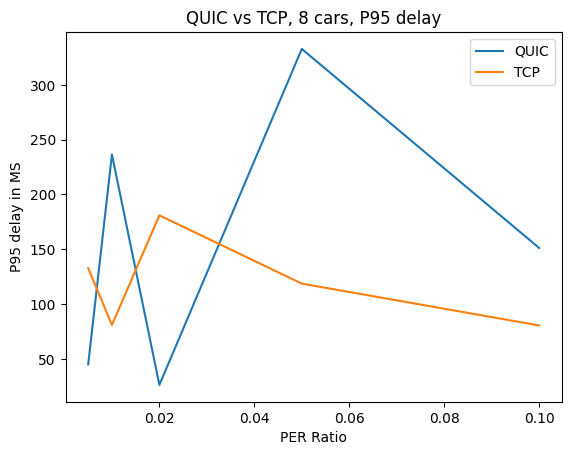

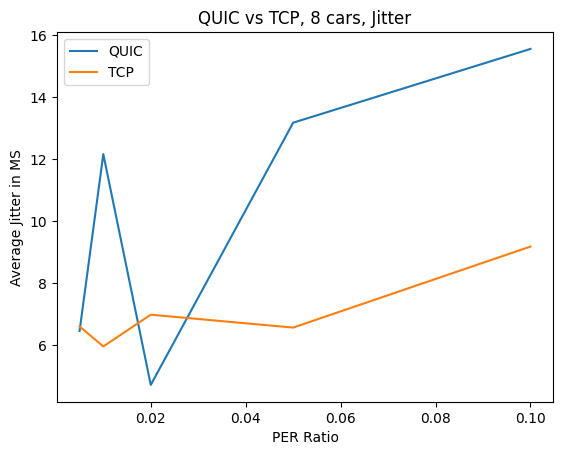

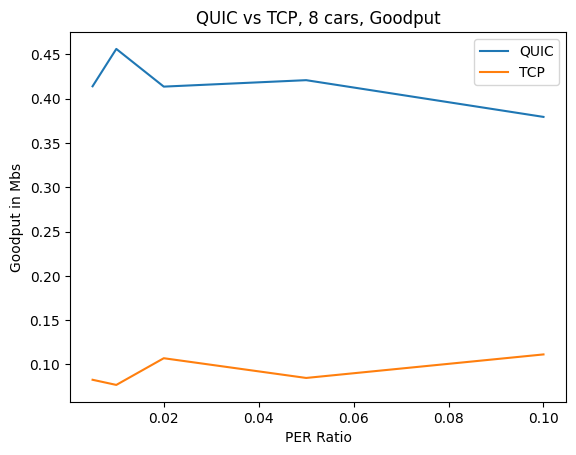

In [15]:
print("Median results")
#Plot AverageDelay
AvgDelayArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,AVGDELAYINDEX))
AvgDelayArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,AVGDELAYINDEX))

PlotQUICVsTCP(AvgDelayArrayQUIC,AvgDelayArrayTCP,"QUIC vs TCP, 8 cars, Average Delay","PER Ratio","Average delay in MS")
##Plot P95 Latency
P95ArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,P95INDEX))
P95ArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,P95INDEX))

PlotQUICVsTCP(P95ArrayQUIC,P95ArrayTCP,"QUIC vs TCP, 8 cars, P95 delay","PER Ratio","P95 delay in MS")
##plot Average Jitter
JitterArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,JITTERINDEX))
JitterArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,JITTERINDEX))

PlotQUICVsTCP(JitterArrayQUIC,JitterArrayTCP,"QUIC vs TCP, 8 cars, Jitter","PER Ratio","Average Jitter in MS")
##Plot goodput
GoodputArrayQUIC=np.loadtxt(CombinedDataOutputFolder+"/"+"QUIC"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,GOODPUTINDEX))
GoodputArrayTCP=np.loadtxt(CombinedDataOutputFolder+"/"+"TCP"+CombinedFileName,delimiter=',',skiprows=1,usecols=(PERINDEX,GOODPUTINDEX))

PlotQUICVsTCP(GoodputArrayQUIC,GoodputArrayTCP,"QUIC vs TCP, 8 cars, Goodput","PER Ratio","Goodput in Mbs")
